# Benchmark Analysis - Input Data Validation

This section performs comprehensive sanity checks on the input data from `plant1.csv`. 

**What you'll see:**
- **Time series plots** showing one year of data for:
  - Electricity prices (€/MWh) - shows price volatility throughout the year
  - Grid consumption (kWh) - total power drawn from the grid
  - Grid injection (kWh) - excess power fed back to the grid
  - PV production (kWh) - solar power generation
  - Total consumption (kWh) - combined energy consumption
  - Inflexible load (kWh) - non-flexible site consumption
  
- **Weekly power plot** showing production, consumption, and injection in kW (converted from 15-minute kWh values)

- **Data quality checks** including:
  - Count of records per variable
  - Missing values (NaN)
  - Statistical summaries (min, max, mean, totals)
  - Volume totals in MWh for energy-related variables

These visualizations help identify data quality issues, seasonal patterns, and understand the baseline energy profile before optimization.

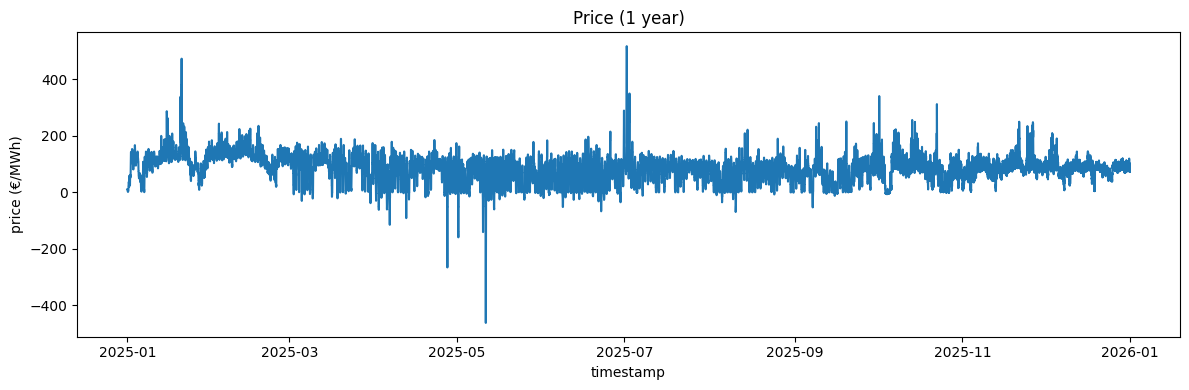

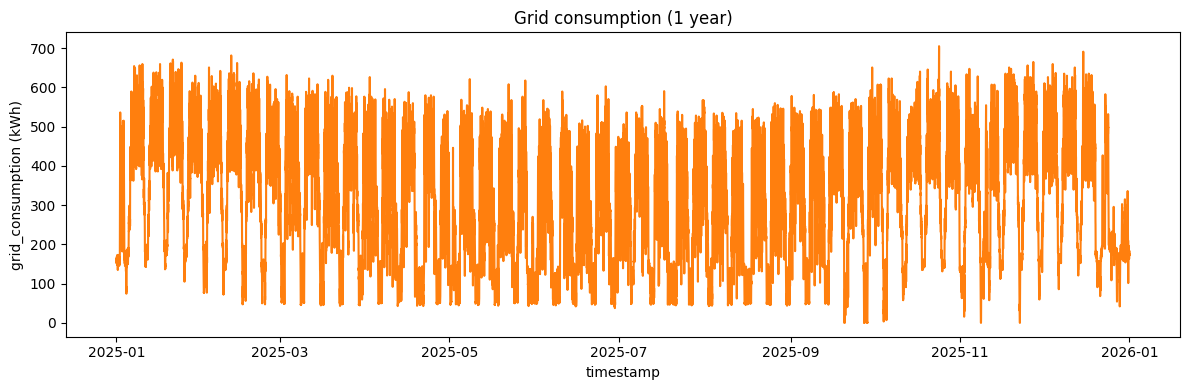

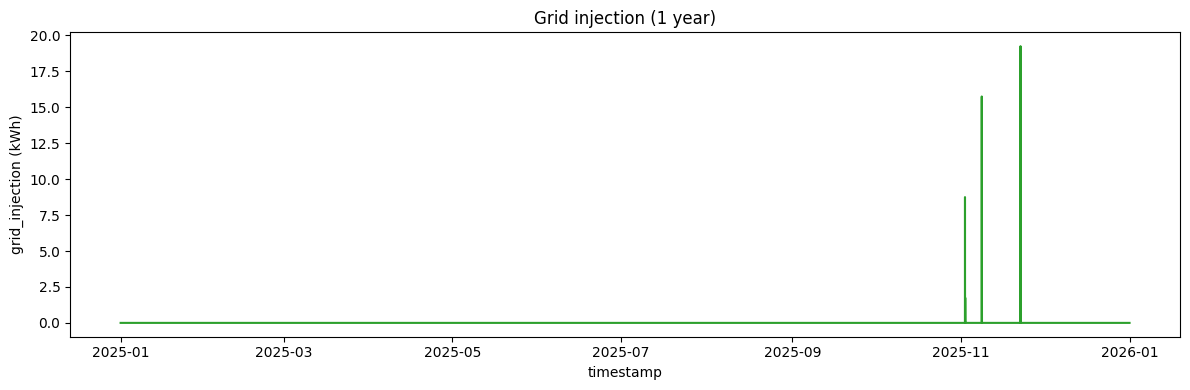

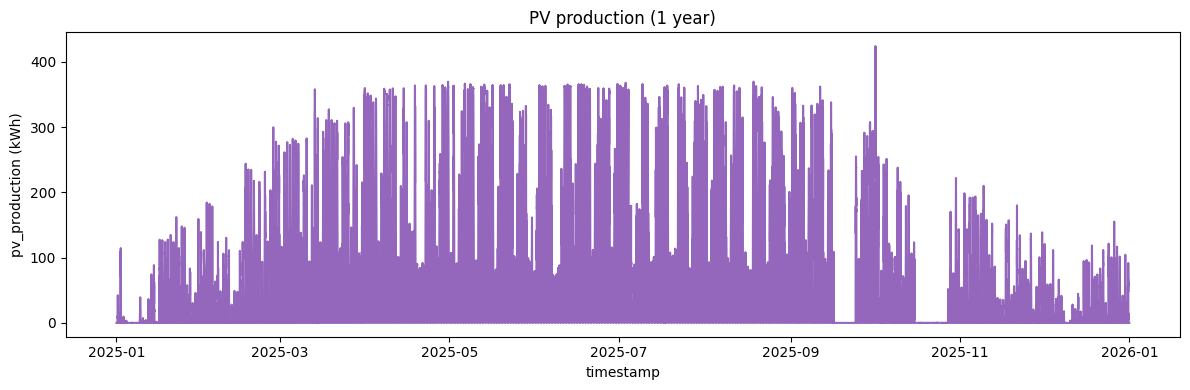

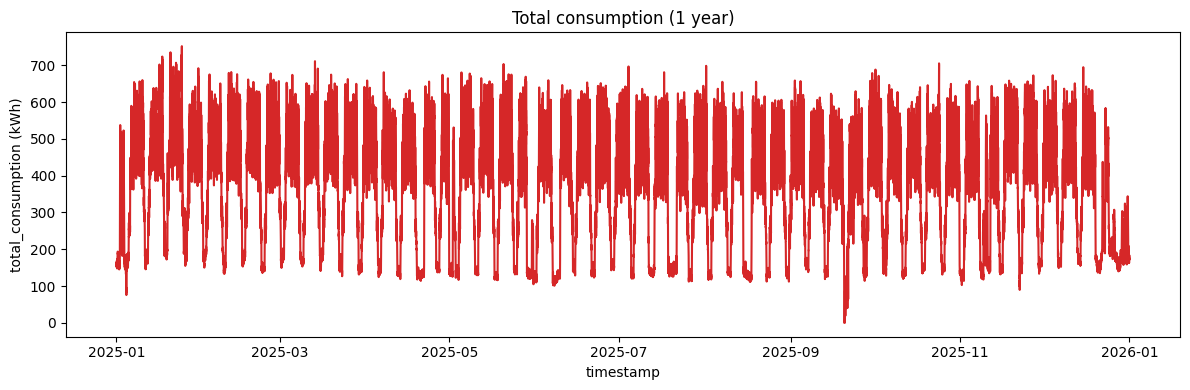

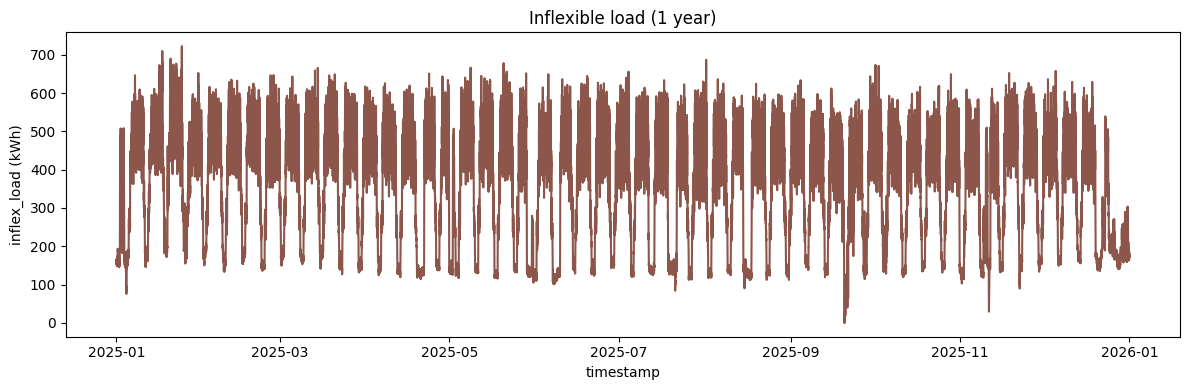

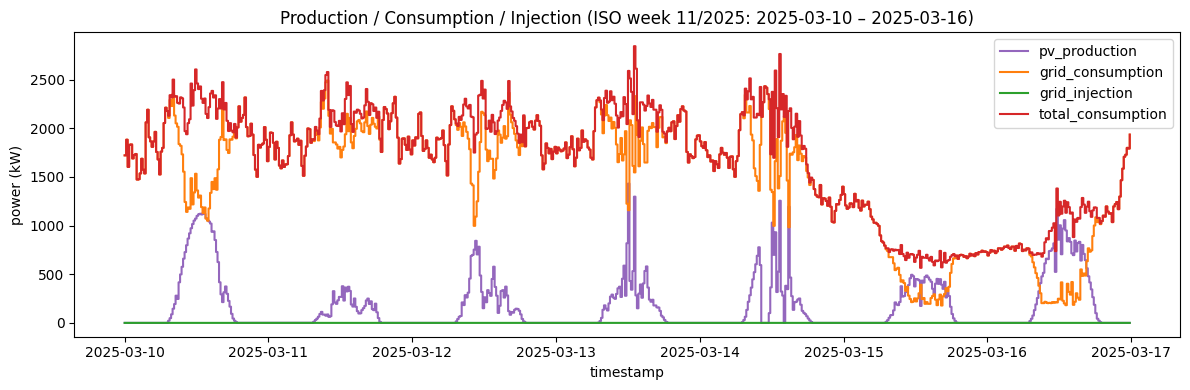

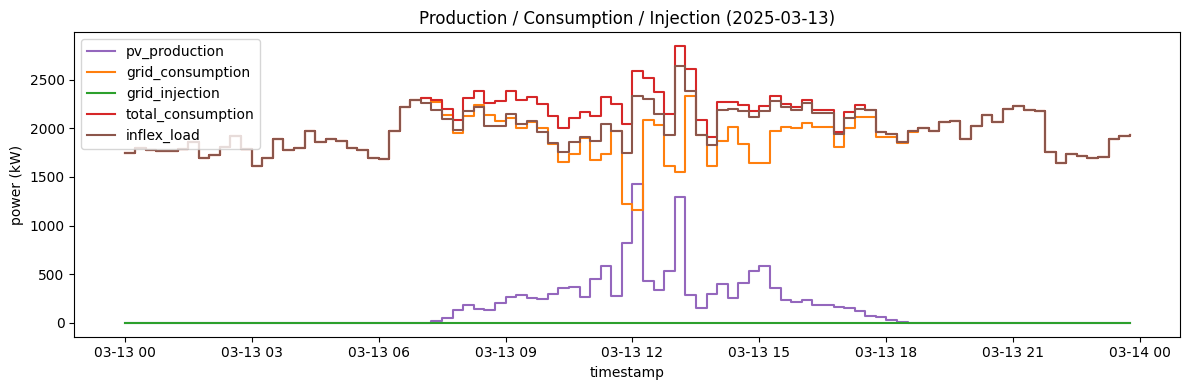

grid_consumption (MWh)     11582.624000
pv_production (MWh)         1817.081400
grid_injection (MWh)           0.173250
total_consumption (MWh)    13399.532150
inflex_load (MWh)          13054.151512
dtype: float64

In [1]:
import datetime as dt

import pandas as pd
import matplotlib.pyplot as plt

# Load plant data
df = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])

# Normalize column names (handles accidental leading/trailing spaces)
df.columns = df.columns.str.strip()

# Take one year of data starting from the first timestamp
start = df["timestamp"].min()
end = start + pd.DateOffset(years=1)

one_year = df[(df["timestamp"] >= start) & (df["timestamp"] < end)]

# Separate plots for price, grid consumption, grid injection, PV production, and total consumption over one year
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_year["timestamp"], one_year["price"], color="tab:blue")
ax.set_ylabel("price (€/MWh)")
ax.set_xlabel("timestamp")
ax.set_title("Price (1 year)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_year["timestamp"], one_year["grid_consumption"], color="tab:orange")
ax.set_ylabel("grid_consumption (kWh)")
ax.set_xlabel("timestamp")
ax.set_title("Grid consumption (1 year)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_year["timestamp"], one_year["grid_injection"], color="tab:green")
ax.set_ylabel("grid_injection (kWh)")
ax.set_xlabel("timestamp")
ax.set_title("Grid injection (1 year)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_year["timestamp"], one_year["pv_production"], color="tab:purple")
ax.set_ylabel("pv_production (kWh)")
ax.set_xlabel("timestamp")
ax.set_title("PV production (1 year)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_year["timestamp"], one_year["total_consumption"], color="tab:red")
ax.set_ylabel("total_consumption (kWh)")
ax.set_xlabel("timestamp")
ax.set_title("Total consumption (1 year)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_year["timestamp"], one_year["inflex_load"], color="tab:brown")
ax.set_ylabel("inflex_load (kWh)")
ax.set_xlabel("timestamp")
ax.set_title("Inflexible load (1 year)")
fig.tight_layout()
plt.show()

# One-week plot: production/consumption/injection in kW
# --- pick any day in the week to plot (ISO week Mon–Sun containing this date) ---
WEEK_OF = "2025-03-13"

week_of = pd.Timestamp(WEEK_OF)
YEAR, ISO_WEEK, _ = week_of.isocalendar()
week_start = pd.Timestamp(dt.date.fromisocalendar(YEAR, ISO_WEEK, 1))
week_end = week_start + pd.Timedelta(days=7)
ts0 = pd.to_datetime(df["timestamp"].iloc[0])
if ts0.tzinfo is not None:
    week_start = week_start.tz_localize(ts0.tzinfo)
    week_end = week_end.tz_localize(ts0.tzinfo)
one_week = df[(df["timestamp"] >= week_start) & (df["timestamp"] < week_end)]

# Convert 15-min kWh to kW (kWh per 15 min * 4)
pv_kw = one_week["pv_production"] * 4
grid_cons_kw = one_week["grid_consumption"] * 4
grid_inj_kw = one_week["grid_injection"] * 4
total_cons_kw = one_week["total_consumption"] * 4

_zoh = dict(drawstyle="steps-post")  # zero-order hold (15-min piecewise-constant kW)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_week["timestamp"], pv_kw, color="tab:purple", label="pv_production", **_zoh)
ax.plot(one_week["timestamp"], grid_cons_kw, color="tab:orange", label="grid_consumption", **_zoh)
ax.plot(one_week["timestamp"], grid_inj_kw, color="tab:green", label="grid_injection", **_zoh)
ax.plot(one_week["timestamp"], total_cons_kw, color="tab:red", label="total_consumption", **_zoh)
ax.set_ylabel("power (kW)")
ax.set_xlabel("timestamp")
ax.set_title(
    f"Production / Consumption / Injection (ISO week {ISO_WEEK}/{YEAR}: "
    f"{week_start.date()} – {(week_end - pd.Timedelta(days=1)).date()})"
)
ax.legend()
fig.tight_layout()
plt.show()

# One-day plot: production/consumption/injection in kW
# --- change only this date (local calendar day in the data timezone) ---
DAY_OF = "2025-03-13"

day_start = pd.Timestamp(DAY_OF).normalize()
day_end = day_start + pd.Timedelta(days=1)
if ts0.tzinfo is not None:
    day_start = day_start.tz_localize(ts0.tzinfo)
    day_end = day_end.tz_localize(ts0.tzinfo)
one_day = df[(df["timestamp"] >= day_start) & (df["timestamp"] < day_end)]

pv_kw_day = one_day["pv_production"] * 4
grid_cons_kw_day = one_day["grid_consumption"] * 4
grid_inj_kw_day = one_day["grid_injection"] * 4
total_cons_kw_day = one_day["total_consumption"] * 4
inflex_kw_day = one_day["inflex_load"] * 4

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_day["timestamp"], pv_kw_day, color="tab:purple", label="pv_production", **_zoh)
ax.plot(one_day["timestamp"], grid_cons_kw_day, color="tab:orange", label="grid_consumption", **_zoh)
ax.plot(one_day["timestamp"], grid_inj_kw_day, color="tab:green", label="grid_injection", **_zoh)
ax.plot(one_day["timestamp"], total_cons_kw_day, color="tab:red", label="total_consumption", **_zoh)
ax.plot(one_day["timestamp"], inflex_kw_day, color="tab:brown", label="inflex_load", **_zoh)
ax.set_ylabel("power (kW)")
ax.set_xlabel("timestamp")
ax.set_title(
    f"Production / Consumption / Injection ({day_start.date()})"
)
ax.legend()
fig.tight_layout()
plt.show()

# Checks for registers (with units)
cols = ["price", "grid_consumption", "grid_injection", "pv_production", "total_consumption", "inflex_load"]
checks = pd.DataFrame({
    "count": one_year[cols].count(),
    "nan": one_year[cols].isna().sum(),
    "total": one_year[cols].sum(numeric_only=True),
    "min": one_year[cols].min(numeric_only=True),
    "max": one_year[cols].max(numeric_only=True),
    "mean": one_year[cols].mean(numeric_only=True),
})

checks.index = [
    "price (€/MWh)",
    "grid_consumption (kWh)",
    "grid_injection (kWh)",
    "pv_production (kWh)",
    "total_consumption (kWh)",
    "inflex_load (kWh)",
]

# Totals sanity check in MWh (volumes are in kWh)
volume_cols = ["grid_consumption", "pv_production", "grid_injection", "total_consumption", "inflex_load"]
mwh_totals = (one_year[volume_cols].sum(numeric_only=True) / 1000).rename(lambda x: f"{x} (MWh)")

checks
mwh_totals

## Thermal Load and Outdoor Temperature Analysis

This section analyzes the thermal load (heating/cooling demand) and outdoor temperature data from `plant1.csv`.

**What you'll see:**

### Data Quality Checks
- **Thermal Load Statistics:**
  - Total records and missing values
  - Zero and negative value checks
  - Statistical summary (min, max, mean, median, standard deviation)
  - Total annual thermal load (kWh and MWh)
  
- **Outdoor Temperature Statistics:**
  - Total records and missing values
  - Temperature range and distribution
  - Statistical summary
  - Warnings for missing or unrealistic values

### Visualizations
- **Thermal Load Plot (1 year)**: 
  - Time series showing heating/cooling demand throughout the year
  - Helps identify seasonal patterns and peak demand periods
  
- **Outdoor Temperature Plot (1 year)**:
  - Time series showing outdoor temperature variations
  - Includes reference line at 24°C (typical indoor target temperature)
  - Shows when heating is needed (temperature below 24°C)
  
- **Combined Plot**:
  - Side-by-side visualization of thermal load and outdoor temperature
  - Helps understand the correlation between outdoor temperature and heating demand

### Monthly Summary Statistics
- Aggregated statistics per month showing:
  - Monthly thermal load totals (MWh)
  - Average, min, max thermal load per 15-minute interval
  - Average, min, max outdoor temperatures
  - Helps identify seasonal patterns and monthly variations

This analysis is essential for understanding building energy requirements and can inform thermal load optimization strategies.

THERMAL LOAD - Sanity Checks
Total records: 35040
Missing values: 0
Zero values: 1920
Negative values: 0

Statistics:
  Min: 0.0000 kWh
  Max: 177.3329 kWh
  Mean: 57.4016 kWh
  Median: 51.1577 kWh
  Std: 44.2721 kWh

Total annual thermal load: 2011352.00 kWh (2011.35 MWh)

OUTDOOR TEMPERATURE - Sanity Checks
Total records: 35040
Missing values: 0
Zero values: 0

Statistics:
  Min: -4.20 °C
  Max: 37.57 °C
  Mean: 12.10 °C
  Median: 12.13 °C
  Std: 7.21 °C


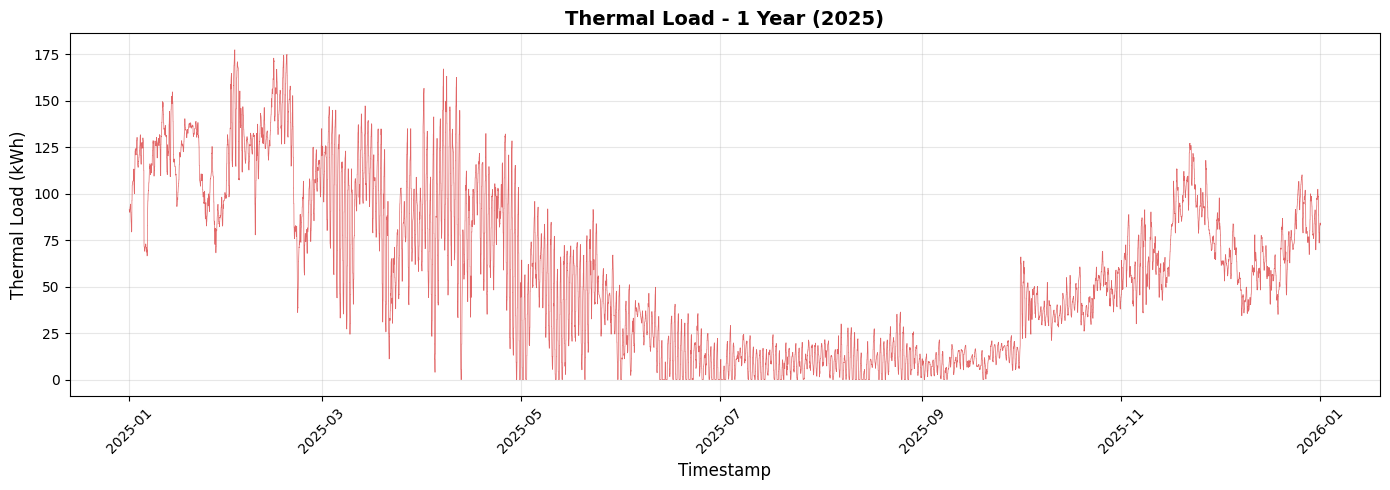

C:\Users\VanAmmeT\AppData\Local\Temp\ipykernel_2152\3276870192.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


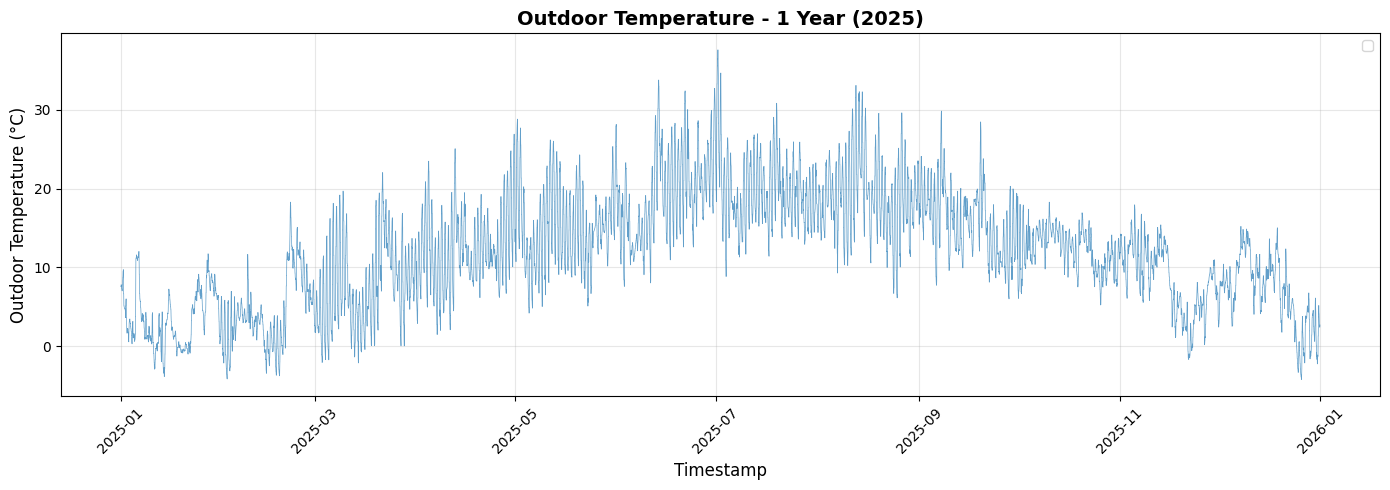

In [2]:
# Extract thermal_load and outdoor_temperature from plant1.csv
# Sanity checks and plots for thermal_load and outdoor_temperature

# Load data if not already loaded (check if df exists)
if 'df' not in globals():
    import pandas as pd
    import matplotlib.pyplot as plt
    df = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])
    df.columns = df.columns.str.strip()

# Create one_year dataframe if not already created
if 'one_year' not in globals():
    start = df["timestamp"].min()
    end = start + pd.DateOffset(years=1)
    one_year = df[(df["timestamp"] >= start) & (df["timestamp"] < end)]

# Extract columns
thermal_load = one_year['thermal_load'].copy()
outdoor_temperature = one_year['outdoor_temperature'].copy()

# Convert outdoor_temperature to numeric (in case it's stored as string)
outdoor_temperature = pd.to_numeric(outdoor_temperature, errors='coerce')

# Sanity checks for thermal_load
print("=" * 60)
print("THERMAL LOAD - Sanity Checks")
print("=" * 60)
print(f"Total records: {len(thermal_load)}")
print(f"Missing values: {thermal_load.isna().sum()}")
print(f"Zero values: {(thermal_load == 0).sum()}")
print(f"Negative values: {(thermal_load < 0).sum()}")
print(f"\nStatistics:")
print(f"  Min: {thermal_load.min():.4f} kWh")
print(f"  Max: {thermal_load.max():.4f} kWh")
print(f"  Mean: {thermal_load.mean():.4f} kWh")
print(f"  Median: {thermal_load.median():.4f} kWh")
print(f"  Std: {thermal_load.std():.4f} kWh")
print(f"\nTotal annual thermal load: {thermal_load.sum():.2f} kWh ({thermal_load.sum()/1000:.2f} MWh)")

# Sanity checks for outdoor_temperature
print("\n" + "=" * 60)
print("OUTDOOR TEMPERATURE - Sanity Checks")
print("=" * 60)
print(f"Total records: {len(outdoor_temperature)}")
print(f"Missing values: {outdoor_temperature.isna().sum()}")
print(f"Zero values: {(outdoor_temperature == 0).sum()}")
print(f"\nStatistics:")
print(f"  Min: {outdoor_temperature.min():.2f} °C")
print(f"  Max: {outdoor_temperature.max():.2f} °C")
print(f"  Mean: {outdoor_temperature.mean():.2f} °C")
print(f"  Median: {outdoor_temperature.median():.2f} °C")
print(f"  Std: {outdoor_temperature.std():.2f} °C")

# Check for missing data patterns
if thermal_load.isna().sum() > 0:
    print(f"\n⚠ WARNING: {thermal_load.isna().sum()} missing thermal_load values found!")
    missing_thermal_indices = thermal_load[thermal_load.isna()].index
    print(f"  Missing at indices: {missing_thermal_indices.tolist()[:20]}..." if len(missing_thermal_indices) > 20 else f"  Missing at indices: {missing_thermal_indices.tolist()}")

if outdoor_temperature.isna().sum() > 0:
    print(f"\n⚠ WARNING: {outdoor_temperature.isna().sum()} missing outdoor_temperature values found!")
    missing_temp_indices = outdoor_temperature[outdoor_temperature.isna()].index
    print(f"  Missing at indices: {missing_temp_indices.tolist()[:20]}..." if len(missing_temp_indices) > 20 else f"  Missing at indices: {missing_temp_indices.tolist()}")

# Check for unrealistic values
unrealistic_thermal = thermal_load[(thermal_load < 0) | (thermal_load > 1000)]
if len(unrealistic_thermal) > 0:
    print(f"\n⚠ WARNING: {len(unrealistic_thermal)} unrealistic thermal_load values found!")
    print(f"  Values outside [0, 1000] kWh range")

unrealistic_temp = outdoor_temperature[(outdoor_temperature < -50) | (outdoor_temperature > 50)]
if len(unrealistic_temp) > 0:
    print(f"\n⚠ WARNING: {len(unrealistic_temp)} unrealistic outdoor_temperature values found!")
    print(f"  Values outside [-50, 50] °C range")

# Plot thermal_load for 1 year
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(one_year['timestamp'], thermal_load, color='tab:red', linewidth=0.5, alpha=0.7)
ax.set_ylabel('Thermal Load (kWh)', fontsize=12)
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_title('Thermal Load - 1 Year (2025)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot outdoor_temperature for 1 year
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(one_year['timestamp'], outdoor_temperature, color='tab:blue', linewidth=0.5, alpha=0.7)
ax.set_ylabel('Outdoor Temperature (°C)', fontsize=12)
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_title('Outdoor Temperature - 1 Year (2025)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Billing Formulas and Parameters

The billing calculations use formulas from `src/billing.py` with parameters from `config/billing.yaml`:

#### Energy-Based Costs
- **Energy Rate** (€/MWh) = Sum of fixed costs:
  - Imbalance cost: 4.612 €/MWh
  - Guarantees of origin: 3.04 €/MWh
  - CHP certificate: 1.836 €/MWh
  - Green energy certificate: 5.738 €/MWh
  - ODV: 4.2294 €/MWh
  - Additional costs: 0.2249 €/MWh
  - Special tax: 10.762 €/MWh
  - **Total fixed rate: ~30.4 €/MWh**

- **Grid Losses** (€/MWh) = Volume-weighted average spot price × Grid losses percentage
  - Grid losses percentage: 1.75% (0.0175)
  - Volume-weighted average spot price = (Σ(volume_kwh[t] × spot_price[t])) / Σ(volume_kwh[t]) = (Spot_cost_eur × 1000) / Volume_kwh
  - Formula: `grid_losses_eur_per_mwh = volume_weighted_avg_spot_price × 0.0175`

- **Total Energy Rate** (€/MWh) = Fixed energy rate + Grid losses
  - Formula: `total_energy_rate = energy_rate_eur_per_mwh + grid_losses_eur_per_mwh`

- **Energy Cost** (€) = Volume (MWh) × Total energy rate
  - Formula: `energy_cost_eur = volume_mwh × total_energy_rate_eur_per_mwh`

#### Spot Price Costs
- **Spot Cost** (€) = Sum of (Volume per interval × Spot price per interval)
  - Formula: `spot_cost_eur = Σ(volume_kwh[t] × spot_price[t] / 1000)` for all intervals t in the month
  - Spot prices are in €/MWh, volumes in kWh (15-minute intervals)

#### Peak-Based Costs
- **Monthly Peak Power** (kW) = Maximum grid consumption power in the month
  - Formula: `monthly_peak_kw = max(grid_consumption_kwh[t] × 4)` for all intervals t in the month
  - Conversion: kWh per 15-min × 4 = kW

- **Access Power** (kW) = Contracted capacity (from config, monthly)
  - Default: 2850 kW for all months (can be optimized)

- **Exceedance** (kW) = Monthly peak - Access power (if positive)
  - Formula: `exceedance_kw = max(0, monthly_peak_kw - access_power_kw)`

- **Rolling Max Exceedance** (kW) = Maximum exceedance over rolling 12-month window
  - Formula: `rolling_max_exceedance_kw[m] = max(exceedance_kw[m-11:m])`

- **Access Power Cost** (€) = Access power × Access power price
  - Access power price: 2.9975458 €/kW/month
  - Formula: `access_cost_eur = access_power_kw × 2.9975458`

- **Monthly Peak Cost** (€) = Monthly peak × Monthly peak price
  - Monthly peak price: 4.2269465 €/kW/month
  - Formula: `monthly_peak_cost_eur = monthly_peak_kw × 4.2269465`

- **Over-Usage Cost** (€) = Rolling max exceedance × Over-usage price
  - Over-usage price: 4.4963187 €/kW/month
  - Formula: `over_usage_cost_eur = rolling_max_exceedance_kw × 4.4963187`

- **Total Peak-Based Cost** (€) = Access cost + Monthly peak cost + Over-usage cost
  - Formula: `peak_based_cost_eur = access_cost_eur + monthly_peak_cost_eur + over_usage_cost_eur`

#### Total Monthly Cost
- **Total Cost** (€) = Energy cost + Spot cost + Peak-based cost
  - Formula: `total_cost_eur = energy_cost_eur + spot_cost_eur + peak_based_cost_eur`

## Offtake Billing Analysis

This section calculates and visualizes the monthly electricity bills for power consumption (offtake) from the grid.

**What you'll see:**
- **Monthly cost breakdown** showing:
  - Energy-based costs (volume × energy rate)
  - Peak-based costs (monthly peak power charges)
  - Spot price costs (variable electricity prices)
  - Total monthly costs

- **Stacked bar chart** visualizing the cost components per month, showing how different cost types contribute to the total bill

- **Monthly peak power chart** displaying the peak offtake power (grid consumption) for each month, which directly impacts peak-based charges

- **Detailed billing tables** including:
  - Monthly volumes (MWh)
  - Monthly peak power (kW)
  - Average spot prices (€/MWh)
  - Grid losses calculation
  - Breakdown of all cost components

- **Example month breakdown** showing detailed calculation formulas for one representative month

This analysis helps understand the cost structure and identify opportunities for cost reduction through peak shaving and load shifting.

### Injection Billing Formulas and Parameters

The injection billing calculations use formulas from `src/billing.py` with parameters from `config/billing.yaml`:

#### Net Injection Price
- **Imbalance Cost** (€/MWh): Deducted from spot price for injection
  - Parameter: 4.612 €/MWh (or 21.148 €/MWh depending on config)
  - This represents the cost of grid imbalances when injecting power

- **Net Injection Price** (€/MWh) = Spot price - Imbalance cost
  - Formula: `net_injection_price_eur_per_mwh = spot_price[t] - imbalance_cost_eur_per_mwh`
  - Calculated per 15-minute interval

#### Monthly Injection Revenue
- **Injection Volume** (MWh) = Sum of injected energy per month
  - Formula: `injected_volume_mwh = Σ(injection_kwh[t] / 1000)` for all intervals t in the month

- **Interval Net Revenue** (€) = Injection volume (MWh) × Net injection price
  - Formula: `interval_net_revenue_eur[t] = (injection_kwh[t] / 1000) × net_injection_price_eur_per_mwh[t]`

- **Monthly Net Revenue** (€) = Sum of interval net revenues
  - Formula: `injection_net_revenue_eur = Σ(interval_net_revenue_eur[t])` for all intervals t in the month

#### Revenue Breakdown
- **Spot Revenue** (€) = Injection volume × Spot price
  - Formula: `injection_spot_revenue_eur = Σ((injection_kwh[t] / 1000) × spot_price[t])`

- **Imbalance Cost** (€) = Injection volume × Imbalance cost
  - Formula: `injection_imbalance_cost_eur = Σ((injection_kwh[t] / 1000) × imbalance_cost_eur_per_mwh)`

- **Net Revenue** (€) = Spot revenue - Imbalance cost
  - Formula: `injection_net_revenue_eur = injection_spot_revenue_eur - injection_imbalance_cost_eur`

**Note:** Injection prices are typically lower than consumption prices because:
1. The imbalance cost is deducted from the spot price
2. Grid operators charge for managing bidirectional power flows
3. The net injection price can be negative if imbalance costs exceed spot prices

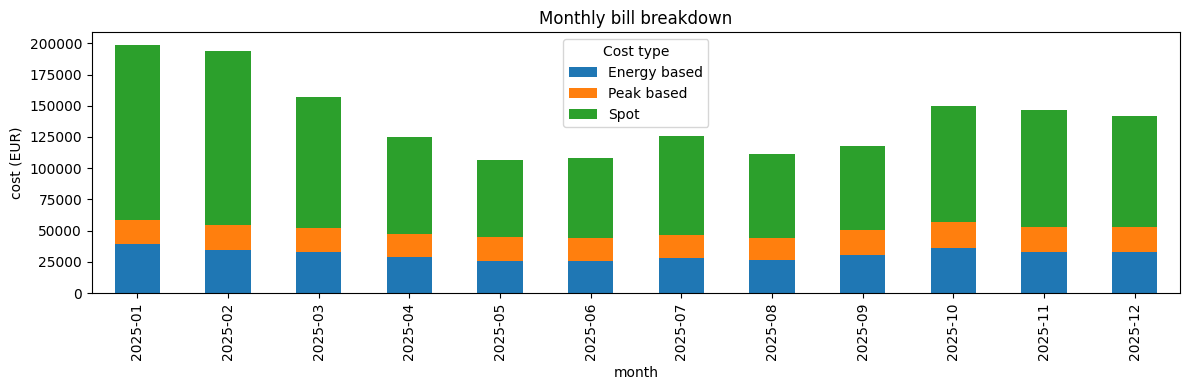

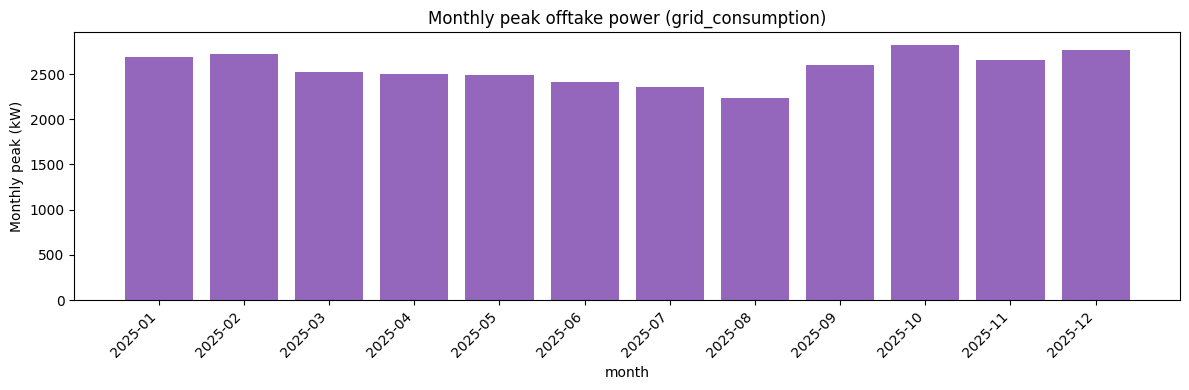

,month,volume_mwh,monthly_peak_kw,monthly_avg_spot_price_eur_per_mwh,grid_losses_eur_per_mwh,energy_rate_eur_per_mwh,energy_cost_eur,peak_based_cost_eur,spot_cost_eur,total_cost_eur
0,2025-01,1190,2684.5,117.9,2.06,167.1,39095.17,19395.65,140326.37,198817.19
1,2025-02,1048,2726.5,133.0,2.33,185.0,34722.26,19730.55,139465.22,193918.03
2,2025-03,1020,2527.0,102.8,1.80,154.0,33250.87,19013.17,104874.16,157138.20
3,2025-04,882,2506.0,87.8,1.54,141.6,28514.15,18924.41,77427.35,124865.91
4,2025-05,806,2485.0,76.6,1.34,132.1,25884.91,18835.64,61687.71,106408.26
5,2025-06,803,2411.5,79.0,1.38,134.3,25830.91,18524.96,63436.26,107792.13
6,2025-07,876,2362.5,89.8,1.57,143.1,28362.97,18317.84,78732.21,125413.02
7,2025-08,829,2240.0,80.4,1.41,134.1,26677.37,17800.04,66617.42,111094.82
8,2025-09,964,2604.0,70.2,1.23,122.3,30852.75,19338.65,67677.46,117868.86
9,2025-10,1131,2821.0,82.2,1.44,132.6,36457.91,20491.95,93032.05,149981.91


,month,monthly_avg_spot_price_eur_per_mwh,grid_losses_eur_per_mwh,volume_mwh,grid_losses_cost_eur,calc
0,2025-01,117.9,2.06,1190,2455.71,117.9 €/MWh × 0.0175 = 2.06 €/MWh
1,2025-02,133.0,2.33,1048,2440.64,133.0 €/MWh × 0.0175 = 2.33 €/MWh
2,2025-03,102.8,1.80,1020,1835.30,102.8 €/MWh × 0.0175 = 1.80 €/MWh
3,2025-04,87.8,1.54,882,1354.98,87.8 €/MWh × 0.0175 = 1.54 €/MWh
4,2025-05,76.6,1.34,806,1079.53,76.6 €/MWh × 0.0175 = 1.34 €/MWh
5,2025-06,79.0,1.38,803,1110.13,79.0 €/MWh × 0.0175 = 1.38 €/MWh
6,2025-07,89.8,1.57,876,1377.81,89.8 €/MWh × 0.0175 = 1.57 €/MWh
7,2025-08,80.4,1.41,829,1165.80,80.4 €/MWh × 0.0175 = 1.41 €/MWh
8,2025-09,70.2,1.23,964,1184.36,70.2 €/MWh × 0.0175 = 1.23 €/MWh
9,2025-10,82.2,1.44,1131,1628.06,82.2 €/MWh × 0.0175 = 1.44 €/MWh


,category,calc,cost_eur
0,Energy based,1189 MWh x 167.1 €/MWh,39095.171603
1,Spot (avg),1189 MWh x 117.9 €/MWh,140326.367947
2,Access cost,2683 kW x 3.0 €/kW,8043.914154
3,Monthly peak cost,2684 kW x 4.2 €/kW,11347.237879
4,Over-usage cost,1 kW x 4.5 €/kW,4.496319
5,Total,sum of all categories,198817.187903


In [3]:
from pathlib import Path
import sys

sys.path.append(str(Path("..") / "src"))

import importlib
import billing

importlib.reload(billing)
from billing import load_billing_config, calculate_monthly_bills
import pandas as pd

config = load_billing_config("../config/billing.yaml")

# Conservative access power (previous max peak + 20 kW), same as notebook 02
df_baseline = df.copy()
ts_raw = df_baseline["timestamp"]
if ts_raw.dtype == "object" or isinstance(
    ts_raw.iloc[0] if len(ts_raw) else None, str
):
    ts_naive = ts_raw.astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    ts_naive = pd.to_datetime(ts_naive, errors="coerce")
else:
    ts_naive = pd.to_datetime(ts_raw, errors="coerce")
    if ts_naive.dt.tz is not None:
        ts_naive = ts_naive.dt.tz_localize(None)

naive_timestamps = pd.to_datetime(
    ts_naive.dt.strftime("%Y-%m-%d %H:%M:%S"),
    format="%Y-%m-%d %H:%M:%S",
)
df_baseline["month"] = naive_timestamps.dt.to_period("M")

MARGIN_KW = 20.0
BASELINE_2024_PEAK_GRID_KW = 2663.5
months_2025 = pd.period_range("2025-01", "2025-12", freq="M")
monthly_peak_baseline_kw = (
    (df_baseline.groupby("month")["grid_consumption"].max() * 4.0)
    .reindex(months_2025)
    .fillna(0.0)
)
cummax_M_minus_1_kw = monthly_peak_baseline_kw.cummax().shift(1)
cummax_M_minus_1_kw.loc[months_2025.min()] = BASELINE_2024_PEAK_GRID_KW
cummax_M_minus_1_kw = cummax_M_minus_1_kw.fillna(BASELINE_2024_PEAK_GRID_KW)
access_power_conservative = cummax_M_minus_1_kw + MARGIN_KW
df_baseline["baseline_access_power_conservative"] = (
    df_baseline["month"].map(access_power_conservative.to_dict()).astype(float)
)

monthly_bills = calculate_monthly_bills(
    df_baseline,
    config,
    access_power_col="baseline_access_power_conservative",
)

numeric_cols = monthly_bills.select_dtypes("number").columns
year_row = monthly_bills[numeric_cols].sum().to_frame().T
year_row["month"] = "Year"
monthly_bills_with_year = pd.concat([monthly_bills, year_row], ignore_index=True)

# Table: monthly costs per category
monthly_cost_table = monthly_bills[[
    "month",
    "volume_mwh",
    "monthly_peak_kw",
    "monthly_avg_spot_price_eur_per_mwh",
    "grid_losses_eur_per_mwh",
    "energy_rate_eur_per_mwh",
    "energy_cost_eur",
    "peak_based_cost_eur",
    "spot_cost_eur",
    "total_cost_eur",
]].copy()

# Example month breakdown (first month in dataset)
example = monthly_bills.iloc[0]
spot_avg_eur_per_mwh = (
    example["spot_cost_eur"] / example["volume_mwh"] if example["volume_mwh"] > 0 else 0.0
)

# Get peak cost prices from config for calculation descriptions
peak_costs = config.get("peak_based_costs", {})
access_power_price = float(peak_costs.get("access_power_price_eur_per_kw", 0.0))
monthly_peak_price = float(peak_costs.get("monthly_peak_price_eur_per_kw", 0.0))
over_usage_price = float(peak_costs.get("over_usage_price_eur_per_kw", 0.0))

example_breakdown = pd.DataFrame(
    {
        "category": [
            "Energy based",
            "Spot (avg)",
            "Access cost",
            "Monthly peak cost",
            "Over-usage cost",
            "Total",
        ],
        "calc": [
            f"{int(example['volume_mwh'])} MWh x {example['energy_rate_eur_per_mwh']:.1f} €/MWh",
            f"{int(example['volume_mwh'])} MWh x {spot_avg_eur_per_mwh:.1f} €/MWh",
            f"{int(example['access_power_kw'])} kW x {access_power_price:.1f} €/kW",
            f"{int(example['monthly_peak_kw'])} kW x {monthly_peak_price:.1f} €/kW",
            f"{int(example['rolling_max_exceedance_kw'])} kW x {over_usage_price:.1f} €/kW",
            "sum of all categories",
        ],
        "cost_eur": [
            example["energy_cost_eur"],
            example["spot_cost_eur"],
            example["access_cost_eur"],
            example["monthly_peak_cost_eur"],
            example["over_usage_cost_eur"],
            example["total_cost_eur"],
        ],
    }
)

# Display all outputs together
from IPython.display import display

# Nice representation: stacked monthly costs
plot_df = monthly_bills.set_index("month")[
    ["energy_cost_eur", "peak_based_cost_eur", "spot_cost_eur"]
]

ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 4))
ax.set_ylabel("cost (EUR)")
ax.set_xlabel("month")
ax.set_title("Monthly bill breakdown")
ax.legend(["Energy based", "Peak based", "Spot"], title="Cost type")
plt.tight_layout()
plt.show()

# Plot monthly peak offtake power (grid_consumption)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_bills["month"], monthly_bills["monthly_peak_kw"], color="tab:purple")
ax.set_ylabel("Monthly peak (kW)")
ax.set_xlabel("month")
ax.set_title("Monthly peak offtake power (grid_consumption)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Display tables with formatting
# Format: volumes as integers, prices with 1 decimal

grid_losses_percentage = float(config.get("energy_based_costs", {}).get("grid_losses_percentage", 0.0))

grid_losses_table = monthly_bills[[
    "month",
    "monthly_avg_spot_price_eur_per_mwh",
    "grid_losses_eur_per_mwh",
    "volume_mwh",
]].copy()

grid_losses_table["grid_losses_cost_eur"] = (
    grid_losses_table["grid_losses_eur_per_mwh"] * grid_losses_table["volume_mwh"]
)

grid_losses_table["calc"] = grid_losses_table.apply(
    lambda r: f"{r['monthly_avg_spot_price_eur_per_mwh']:.1f} €/MWh × {grid_losses_percentage:.4f} = {r['grid_losses_eur_per_mwh']:.2f} €/MWh",
    axis=1,
)

# Monthly bill summary (includes grid-losses columns)
display(
    monthly_cost_table.style.format({
        "volume_mwh": "{:.0f}",
        "monthly_peak_kw": "{:.1f}",
        "monthly_avg_spot_price_eur_per_mwh": "{:.1f}",
        "grid_losses_eur_per_mwh": "{:.2f}",
        "energy_rate_eur_per_mwh": "{:.1f}",
        "energy_cost_eur": "{:.2f}",
        "peak_based_cost_eur": "{:.2f}",
        "spot_cost_eur": "{:.2f}",
        "total_cost_eur": "{:.2f}",
    })
)

# Grid-losses calculation per month
# (avg spot × % -> €/MWh, and multiplied by monthly volume -> €)
display(
    grid_losses_table[[
        "month",
        "monthly_avg_spot_price_eur_per_mwh",
        "grid_losses_eur_per_mwh",
        "volume_mwh",
        "grid_losses_cost_eur",
        "calc",
    ]].style.format({
        "monthly_avg_spot_price_eur_per_mwh": "{:.1f}",
        "grid_losses_eur_per_mwh": "{:.2f}",
        "volume_mwh": "{:.0f}",
        "grid_losses_cost_eur": "{:.2f}",
    })
)

display(example_breakdown)

## Injection Billing Analysis

This section calculates the revenue from injecting excess power (primarily from PV production) back into the grid.

**What you'll see:**
- **Monthly injection revenue** showing how much money is earned from selling excess electricity to the grid
- **Injection volumes** (MWh) per month
- **Injection prices** (€/MWh) - typically lower than consumption prices
- **Net revenue calculations** showing the financial benefit of PV production

This analysis quantifies the value of renewable energy generation and helps understand the economic impact of grid injection.

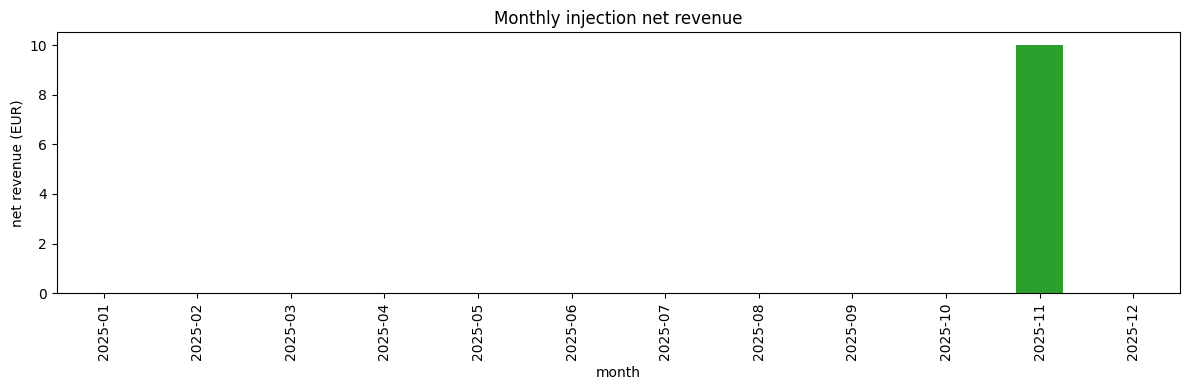

,month,injected_volume_mwh,avg_spot_price_eur_per_mwh,avg_net_injection_price_eur_per_mwh,imbalance_cost_eur_per_mwh,injection_spot_revenue_eur,injection_imbalance_cost_eur,injection_net_revenue_eur
0,2025-01,0.0,0.0,0.0,20.00,0.00,0.00,0.00
1,2025-02,0.0,0.0,0.0,20.00,0.00,0.00,0.00
2,2025-03,0.0,0.0,0.0,20.00,0.00,0.00,0.00
3,2025-04,0.0,0.0,0.0,20.00,0.00,0.00,0.00
4,2025-05,0.0,0.0,0.0,20.00,0.00,0.00,0.00
5,2025-06,0.0,0.0,0.0,20.00,0.00,0.00,0.00
6,2025-07,0.0,0.0,0.0,20.00,0.00,0.00,0.00
7,2025-08,0.0,0.0,0.0,20.00,0.00,0.00,0.00
8,2025-09,0.0,0.0,0.0,20.00,0.00,0.00,0.00
9,2025-10,0.0,0.0,0.0,20.00,0.00,0.00,0.00


In [4]:
# Injection billing (monthly)
from IPython.display import display
import importlib
import billing

# Ensure the updated function is loaded (avoid stale module state)
importlib.reload(billing)

monthly_injection_bills = billing.calculate_monthly_injection_bills(df, config)

# Simple visualisation: monthly net revenue from injection
plot_inj = monthly_injection_bills.set_index("month")[[
    "injection_net_revenue_eur",
]]

ax = plot_inj.plot(kind="bar", figsize=(12, 4), legend=False, color="tab:green")
ax.set_ylabel("net revenue (EUR)")
ax.set_xlabel("month")
ax.set_title("Monthly injection net revenue")
plt.tight_layout()
plt.show()

# Nice formatting for display
display(
    monthly_injection_bills.style.format({
        "injected_volume_mwh": "{:.1f}",
        "avg_spot_price_eur_per_mwh": "{:.1f}",
        "avg_net_injection_price_eur_per_mwh": "{:.1f}",
        "imbalance_cost_eur_per_mwh": "{:.2f}",
        "injection_spot_revenue_eur": "{:.2f}",
        "injection_imbalance_cost_eur": "{:.2f}",
        "injection_net_revenue_eur": "{:.2f}",
    })
)

## Electric Vehicle (EV) Data Visualization

This section analyzes the EV charging patterns and their impact on the energy system.

**What you'll see:**
- **EV charging patterns** over time showing when vehicles are charging
- **EV energy consumption** (kWh) per 15-minute interval
- **Charging power** (kW) profiles
- **Daily/weekly charging patterns** to identify typical charging behaviors
- **Statistics** on EV charging including:
  - Total EV energy consumption
  - Peak charging power
  - Average charging power
  - Charging frequency and duration

These visualizations help understand the baseline EV charging behavior before optimization, which is crucial for designing effective charging strategies.

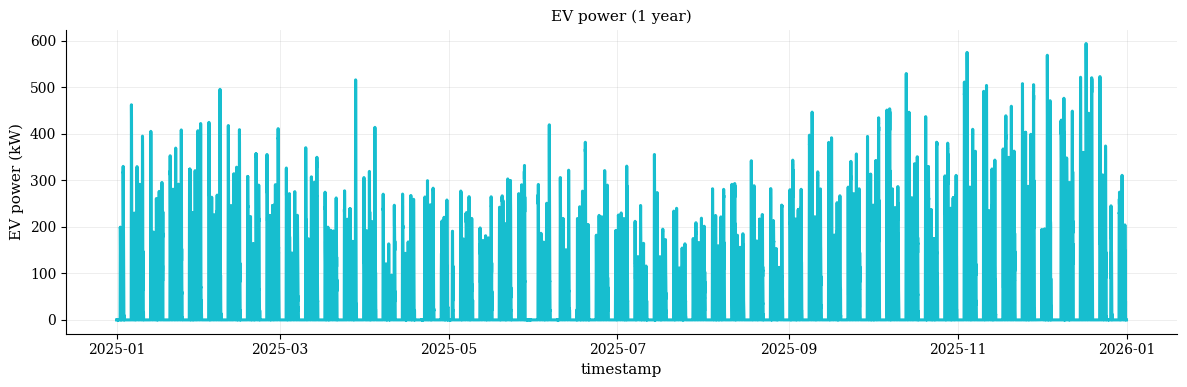

Total yearly EV volume: 345380.6 kWh (345.381 MWh)

Monthly EV volumes (first year):
             ev_kwh     ev_mwh
month                         
2025-01  31769.3750  31.769375
2025-02  30538.3125  30.538312
2025-03  27423.1250  27.423125
2025-04  23056.8750  23.056875
2025-05  21837.3750  21.837375
2025-06  22832.0625  22.832062
2025-07  21220.0000  21.220000
2025-08  22350.0000  22.350000
2025-09  31520.0000  31.520000
2025-10  36940.0000  36.940000
2025-11  37230.0000  37.230000
2025-12  38663.5125  38.663512


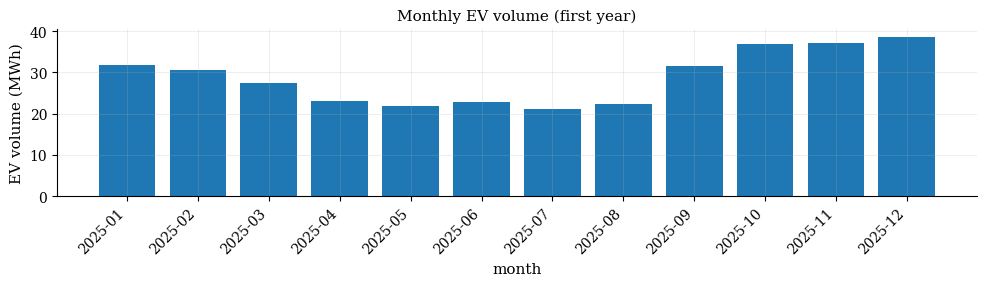

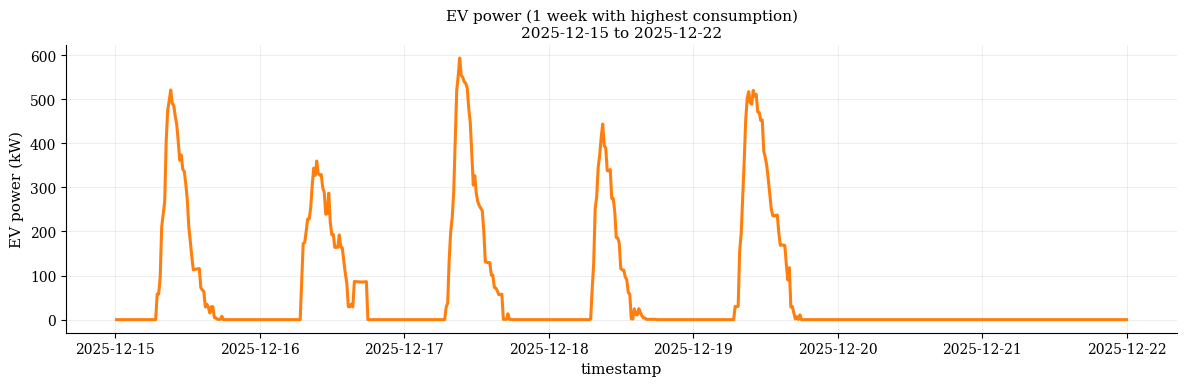

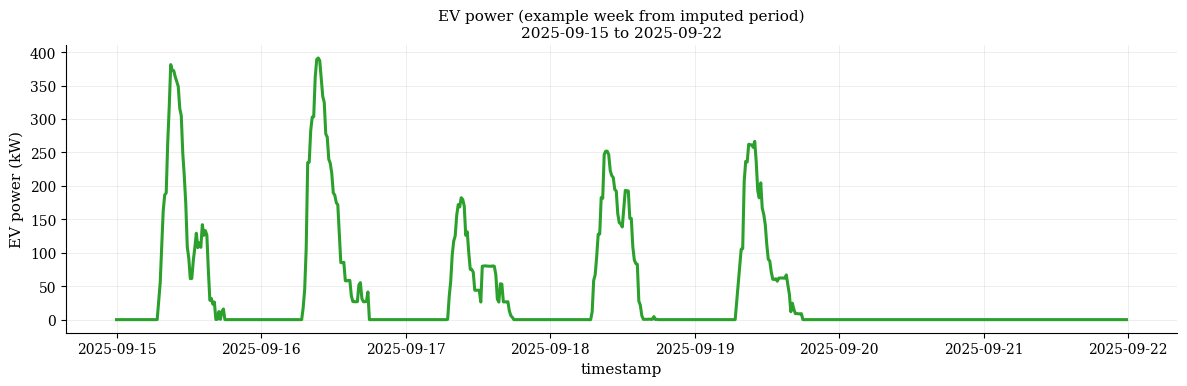

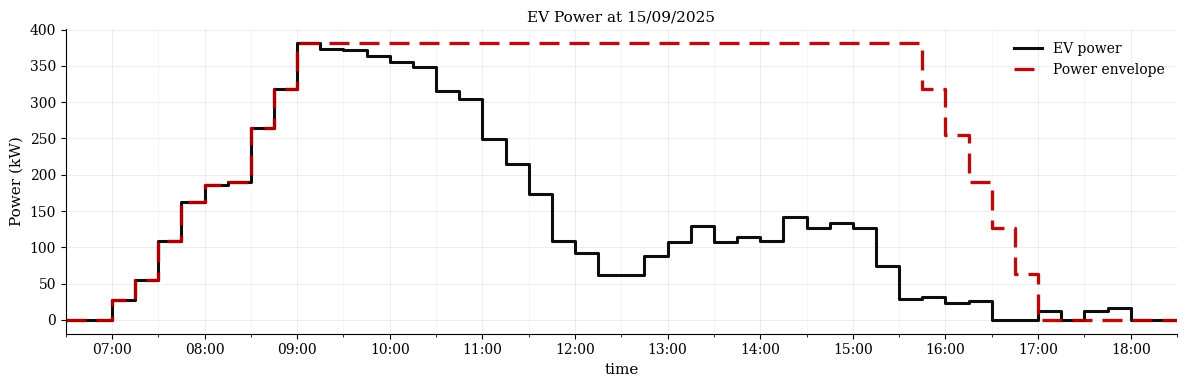

In [5]:
# EV visualisations (year and peak week)
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

# --- KU Leuven thesis plotting style (reusable) ---
THESIS_STYLE = {
    # Typography
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Clean KU Leuven-style axes
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,

    # Black / red palette (reused across thesis figures)
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.prop_cycle": mpl.cycler(color=["black", "#b30000"]),

    # Grid (major + minor)
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,

    # Lines / export
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}


def apply_thesis_style() -> None:
    mpl.rcParams.update(THESIS_STYLE)


apply_thesis_style()

# Ensure latest data (including ev in kWh/interval) is loaded
# NOTE: plant1.csv timestamps include a fixed offset (+01:00/+02:00). For plotting and
# envelope logic we treat these as **local Belgium clock time** by stripping the offset.
df = pd.read_csv("../data/plant1.csv")
df["timestamp"] = (
    df["timestamp"].astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# One year from first timestamp
start = df["timestamp"].min()
end = start + pd.DateOffset(years=1)

year = df[(df["timestamp"] >= start) & (df["timestamp"] < end)].copy()
# Convert kWh/15min -> kW for plotting (×4)
year["ev_kw"] = year["ev"].astype(float) * 4.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year["timestamp"], year["ev_kw"], color="tab:cyan")
ax.set_ylabel("EV power (kW)")
ax.set_xlabel("timestamp")
ax.set_title("EV power (1 year)")
fig.tight_layout()
plt.show()

# Total yearly EV volume (kWh and MWh)
# ev is kWh per 15-min interval
yearly_ev_kwh = year["ev"].astype(float).sum()
yearly_ev_mwh = yearly_ev_kwh / 1000.0
print(f"Total yearly EV volume: {yearly_ev_kwh:.1f} kWh ({yearly_ev_mwh:.3f} MWh)")

# Monthly EV volumes within the first year (local time months)
# Derive month labels directly from the timestamp string (YYYY-MM), which is local time in the CSV.
month_labels = year["timestamp"].astype(str).str.slice(0, 7)
monthly_ev_kwh = (
    pd.DataFrame({
        "month": month_labels,
        "ev": year["ev"].astype(float),
    })
    .groupby("month")["ev"]
    .sum()
)
monthly_ev = monthly_ev_kwh.to_frame(name="ev_kwh")
monthly_ev["ev_mwh"] = monthly_ev["ev_kwh"] / 1000.0
print("\nMonthly EV volumes (first year):")
print(monthly_ev)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(monthly_ev.index, monthly_ev["ev_mwh"], color="tab:blue")
ax.set_ylabel("EV volume (MWh)")
ax.set_xlabel("month")
ax.set_title("Monthly EV volume (first year)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Find 1-week window with highest EV consumption, starting on a Monday
# Build a proper DatetimeIndex and use weekly resampling (weeks ending on Monday).
# Timestamps are treated as local (naive) clock time; do not force UTC here.
idx = pd.to_datetime(df["timestamp"], errors="coerce")
ev_series = pd.Series(df["ev"].astype(float).values, index=idx)
weekly_energy = ev_series.resample("W-MON", label="right", closed="right").sum()
week_end = weekly_energy.idxmax()  # Monday end (local naive)
week_start = week_end - pd.Timedelta(days=7)

week_mask = (idx > week_start) & (idx <= week_end)
week = df.loc[week_mask].copy()
week["ev_kw"] = week["ev"].astype(float) * 4.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(week["timestamp"], week["ev_kw"], color="tab:orange")
ax.set_ylabel("EV power (kW)")
ax.set_xlabel("timestamp")
ax.set_title(f"EV power (1 week with highest consumption)\n{week_start.date()} to {week_end.date()}")
fig.tight_layout()
plt.show()

# Example week from imputed (previously missing) period
# Choose the first Monday within 2025-08 as a starting point.
local_ts = pd.to_datetime(df["timestamp"], errors="coerce")
local_dates = local_ts.dt.date
in_gap = (local_dates >= pd.to_datetime("2025-09-15").date()) & (
    local_dates <= pd.to_datetime("2025-12-02").date()
)
mondays_in_gap = local_ts[(in_gap) & (local_ts.dt.weekday == 0)]
example_start = mondays_in_gap.min()
example_end = example_start + pd.Timedelta(days=7)

example_week = df[(df["timestamp"] >= example_start) & (df["timestamp"] < example_end)].copy()
example_week["ev_kw"] = example_week["ev"].astype(float) * 4.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(example_week["timestamp"], example_week["ev_kw"], color="tab:green")
ax.set_ylabel("EV power (kW)")
ax.set_xlabel("timestamp")
ax.set_title(
    f"EV power (example week from imputed period)\n{example_start.date()} to {example_end.date()}"
)
fig.tight_layout()
plt.show()

# --- Extra plot: one day + envelope (06:30-18:30) ---
# Take the first day of the example week.
day_start = pd.Timestamp(example_start).floor("D")
day_end = day_start + pd.Timedelta(days=1)

day = df[(df["timestamp"] >= day_start) & (df["timestamp"] < day_end)].copy()
day["ev_kw"] = day["ev"].astype(float) * 4.0

# Limit plot window
win_start = day_start + pd.Timedelta(hours=6, minutes=30)
win_end = day_start + pd.Timedelta(hours=18, minutes=30)
day_win = day[(day["timestamp"] >= win_start) & (day["timestamp"] <= win_end)].copy()

# Power envelope for the day: cumulative maximum (cummax) until 15:30,
# then linearly ramp down to 0 by 17:00.
# Ensure timestamp is datetime (should already be from the loader, but keep safe)
day_win["timestamp"] = pd.to_datetime(day_win["timestamp"], errors="coerce")
day_win = day_win.dropna(subset=["timestamp"]).sort_values("timestamp")
_envelope_cummax = day_win["ev_kw"].cummax()

_h = day_win["timestamp"].dt.hour + day_win["timestamp"].dt.minute / 60.0
ramp_start = 15.5
ramp_end = 17.0

# Value at ramp start = cummax at (or just before) 15:30
if (_h <= ramp_start).any():
    p_at_ramp_start = float(_envelope_cummax[_h <= ramp_start].iloc[-1])
else:
    p_at_ramp_start = float(_envelope_cummax.iloc[0]) if len(_envelope_cummax) else 0.0

# Piecewise envelope
day_win["ev_envelope_kw"] = _envelope_cummax
_in_ramp = (_h > ramp_start) & (_h < ramp_end)
day_win.loc[_in_ramp, "ev_envelope_kw"] = p_at_ramp_start * (ramp_end - _h[_in_ramp]) / (ramp_end - ramp_start)
day_win.loc[_h >= ramp_end, "ev_envelope_kw"] = 0.0

fig, ax = plt.subplots(figsize=(12, 4))

# Step-style plotting: hold value constant over each 15-min interval.
ax.step(
    day_win["timestamp"],
    day_win["ev_kw"],
    where="post",
    color="black",
    lw=2.2,
    alpha=0.95,
    label="EV power",
    zorder=2,
)
ax.step(
    day_win["timestamp"],
    day_win["ev_envelope_kw"],
    where="post",
    color="#b30000",
    lw=2.4,
    ls=(0, (6, 3)),
    alpha=0.95,
    label="Power envelope",
    zorder=3,
)
ax.set_ylabel("Power (kW)")
ax.set_xlabel("time")

ax.set_title(f"EV Power at {day_start.strftime('%d/%m/%Y')}")
ax.set_xlim(win_start, win_end)

# More x-labels/dividers: hourly labels + 30-min minor dividers
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="x", alpha=0.15)

ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

## Impact of Uncontrolled EV Charging (Baseline)

This section visualizes the impact of uncontrolled EV charging on the energy system without any optimization.

**What you'll see:**
- **Grid consumption comparison** showing how EV loads increase peak demand:
  - Baseline consumption (without EV)
  - Consumption with uncontrolled EV charging
  - Difference highlighting the additional load

- **Peak power analysis** comparing monthly peaks:
  - Baseline monthly peak power
  - Monthly peak power with EV charging
  - Peak power increases due to EV loads

- **Cost impact analysis** showing:
  - Monthly cost increases due to EV charging
  - Breakdown by cost component (energy, peak, spot)
  - Cost per MWh of EV charging
  - Annual total cost impact

- **Time-of-day analysis** showing when uncontrolled EV charging occurs and its correlation with:
  - Electricity prices (often charging during expensive periods)
  - PV production availability (missing opportunities to charge with solar)
  - Grid consumption patterns (adding to peak demand)

- **Visual comparisons** including:
  - Side-by-side plots of grid consumption before and after EV charging
  - Peak power increases visualization
  - Cost implications of charging during expensive periods

This baseline analysis establishes the reference point for comparing optimized charging strategies and quantifies the potential benefits of load shifting and peak shaving.

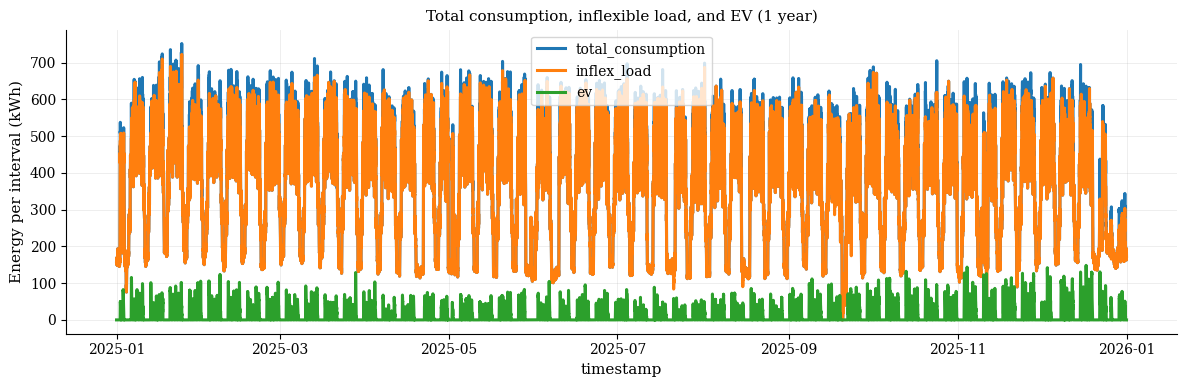

Total yearly total_consumption: 13399532.1 kWh (13399.532 MWh)
Total yearly inflex_load:       13054151.5 kWh (13054.152 MWh)
Total yearly ev:               345380.6 kWh (345.381 MWh)


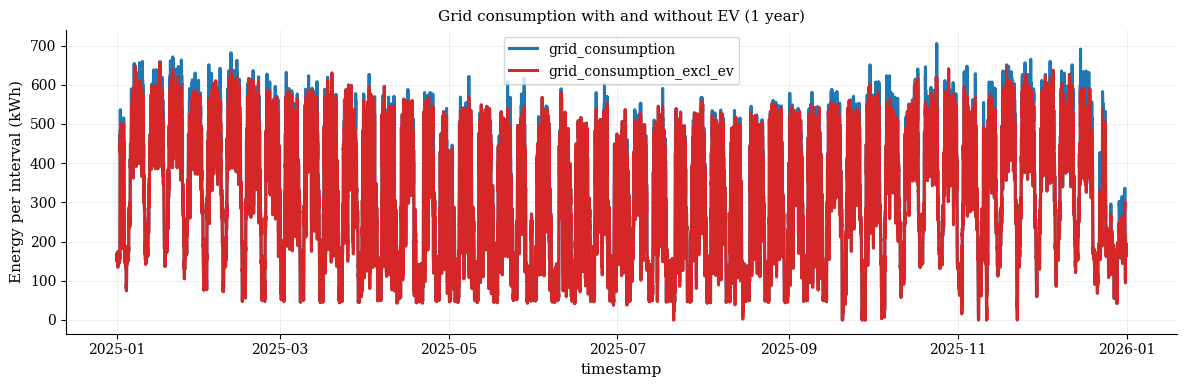

Total yearly grid_consumption:           11582624.0 kWh (11582.624 MWh)
Total yearly grid_consumption_excl_ev:  11237375.3 kWh (11237.375 MWh)
EV-attributed grid consumption:         345248.7 kWh (345.249 MWh)


In [6]:
# Visualise total_consumption, inflex_load and ev for 1 year and compute totals
import pandas as pd
import matplotlib.pyplot as plt

# Load latest data (with ev and inflex_load)
df = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])

# One year from first timestamp
start = df["timestamp"].min()
end = start + pd.DateOffset(years=1)

year = df[(df["timestamp"] >= start) & (df["timestamp"] < end)].copy()

# Plot the three series over one year
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year["timestamp"], year["total_consumption"].astype(float), label="total_consumption", color="tab:blue")
ax.plot(year["timestamp"], year["inflex_load"].astype(float), label="inflex_load", color="tab:orange")
ax.plot(year["timestamp"], year["ev"].astype(float), label="ev", color="tab:green")

ax.set_ylabel("Energy per interval (kWh)")
ax.set_xlabel("timestamp")
ax.set_title("Total consumption, inflexible load, and EV (1 year)")
ax.legend()
fig.tight_layout()
plt.show()

# Totals over the year (kWh and MWh)
total_tc_kwh = year["total_consumption"].astype(float).sum()
total_inflex_kwh = year["inflex_load"].astype(float).sum()
total_ev_kwh = year["ev"].astype(float).sum()

print(f"Total yearly total_consumption: {total_tc_kwh:.1f} kWh ({total_tc_kwh/1000.0:.3f} MWh)")
print(f"Total yearly inflex_load:       {total_inflex_kwh:.1f} kWh ({total_inflex_kwh/1000.0:.3f} MWh)")
print(f"Total yearly ev:               {total_ev_kwh:.1f} kWh ({total_ev_kwh/1000.0:.3f} MWh)")

# Visualise grid_consumption and grid_consumption_excl_ev for 1 year and compute totals
import pandas as pd
import matplotlib.pyplot as plt

# Load latest data (with grid_consumption_excl_ev)
df = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])

# One year from first timestamp
start = df["timestamp"].min()
end = start + pd.DateOffset(years=1)

year = df[(df["timestamp"] >= start) & (df["timestamp"] < end)].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(year["timestamp"], year["grid_consumption"].astype(float), label="grid_consumption", color="tab:blue")
ax.plot(year["timestamp"], year["grid_consumption_excl_ev"].astype(float), label="grid_consumption_excl_ev", color="tab:red")

ax.set_ylabel("Energy per interval (kWh)")
ax.set_xlabel("timestamp")
ax.set_title("Grid consumption with and without EV (1 year)")
ax.legend()
fig.tight_layout()
plt.show()

# Totals over the year
total_gc_kwh = year["grid_consumption"].astype(float).sum()
total_gc_excl_ev_kwh = year["grid_consumption_excl_ev"].astype(float).sum()

ev_grid_component_kwh = total_gc_kwh - total_gc_excl_ev_kwh

print(f"Total yearly grid_consumption:           {total_gc_kwh:.1f} kWh ({total_gc_kwh/1000.0:.3f} MWh)")
print(f"Total yearly grid_consumption_excl_ev:  {total_gc_excl_ev_kwh:.1f} kWh ({total_gc_excl_ev_kwh/1000.0:.3f} MWh)")
print(f"EV-attributed grid consumption:         {ev_grid_component_kwh:.1f} kWh ({ev_grid_component_kwh/1000.0:.3f} MWh)")


In [7]:
# Billing comparison: baseline (no EV) vs uncontrolled EV charging using grid_consumption_excl_ev
import pandas as pd
from pathlib import Path
import sys

# Ensure src on path and billing imported
sys.path.append(str(Path("..") / "src"))
import importlib
import billing
importlib.reload(billing)
from billing import load_billing_config, calculate_monthly_bills

# Load config
config = load_billing_config("../config/billing.yaml")

# Load latest plant data
df_b = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])
# Normalise column names
df_b.columns = df_b.columns.str.strip()

# Conservative access power from full-site grid peaks (same series for both volume columns)
ts_raw = df_b["timestamp"]
if ts_raw.dtype == "object" or isinstance(
    ts_raw.iloc[0] if len(ts_raw) else None, str
):
    ts_naive = ts_raw.astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    ts_naive = pd.to_datetime(ts_naive, errors="coerce")
else:
    ts_naive = pd.to_datetime(ts_raw, errors="coerce")
    if ts_naive.dt.tz is not None:
        ts_naive = ts_naive.dt.tz_localize(None)

naive_timestamps = pd.to_datetime(
    ts_naive.dt.strftime("%Y-%m-%d %H:%M:%S"),
    format="%Y-%m-%d %H:%M:%S",
)
df_b["month"] = naive_timestamps.dt.to_period("M")

MARGIN_KW = 20.0
BASELINE_2024_PEAK_GRID_KW = 2663.5
months_2025 = pd.period_range("2025-01", "2025-12", freq="M")
monthly_peak_baseline_kw = (
    (df_b.groupby("month")["grid_consumption"].max() * 4.0)
    .reindex(months_2025)
    .fillna(0.0)
)
cummax_M_minus_1_kw = monthly_peak_baseline_kw.cummax().shift(1)
cummax_M_minus_1_kw.loc[months_2025.min()] = BASELINE_2024_PEAK_GRID_KW
cummax_M_minus_1_kw = cummax_M_minus_1_kw.fillna(BASELINE_2024_PEAK_GRID_KW)
access_power_conservative = cummax_M_minus_1_kw + MARGIN_KW
df_b["baseline_access_power_conservative"] = (
    df_b["month"].map(access_power_conservative.to_dict()).astype(float)
)

# Baseline: grid_consumption_excl_ev (no EV on grid)
monthly_baseline = calculate_monthly_bills(
    df_b,
    config,
    volume_col="grid_consumption_excl_ev",
    access_power_col="baseline_access_power_conservative",
)

# Uncontrolled EV charging: full grid_consumption
monthly_ev = calculate_monthly_bills(
    df_b,
    config,
    volume_col="grid_consumption",
    access_power_col="baseline_access_power_conservative",
)

# Align on month
base = monthly_baseline.set_index("month")
with_ev = monthly_ev.set_index("month")

# Build comparison table per month
cols_cost = [
    "energy_cost_eur",
    "peak_based_cost_eur",
    "spot_cost_eur",
    "total_cost_eur",
]

comp = pd.DataFrame(index=base.index)
for c in cols_cost:
    comp[(c, "baseline")] = base[c]
    comp[(c, "with_ev")] = with_ev[c]
    comp[(c, "delta")] = with_ev[c] - base[c]

# Monthly max peaks
comp[("monthly_peak_kw", "baseline")] = base["monthly_peak_kw"]
comp[("monthly_peak_kw", "with_ev")] = with_ev["monthly_peak_kw"]
comp[("monthly_peak_kw", "delta")] = (
    with_ev["monthly_peak_kw"] - base["monthly_peak_kw"]
)

# Access power (same conservative series for both volume columns)
comp[("access_power_kw", "baseline")] = base["access_power_kw"]
comp[("access_power_kw", "with_ev")] = with_ev["access_power_kw"]
comp[("access_power_kw", "delta")] = (
    with_ev["access_power_kw"] - base["access_power_kw"]
)

# Yearly totals and yearly max peaks
year_total_base = base[cols_cost].sum()
year_total_ev = with_ev[cols_cost].sum()
year_delta = year_total_ev - year_total_base

yearly_peak_base = base["monthly_peak_kw"].max()
yearly_peak_ev = with_ev["monthly_peak_kw"].max()
yearly_peak_delta = yearly_peak_ev - yearly_peak_base

# Access power (max across months, should be same for baseline and with_ev)
yearly_access_power_base = base["access_power_kw"].max()
yearly_access_power_ev = with_ev["access_power_kw"].max()
yearly_access_power_delta = yearly_access_power_ev - yearly_access_power_base

# Cost of EV charging (1 year) = difference in total annual bill
cost_ev_year_eur = float(year_delta["total_cost_eur"])

# Calculate yearly EV volume in MWh
yearly_ev_kwh = df_b["ev"].astype(float).sum()
yearly_ev_mwh = yearly_ev_kwh / 1000.0

summary_rows = []
for c in cols_cost:
    delta_value = year_delta[c]
    delta_per_mwh = delta_value / yearly_ev_mwh if yearly_ev_mwh > 0 else 0.0
    summary_rows.append(
        {
            "metric": f"{c} (EUR)",
            "baseline": year_total_base[c],
            "with_ev": year_total_ev[c],
            "delta": delta_value,
            "delta/MWh": delta_per_mwh,
        }
    )
summary_rows.append(
    {
        "metric": "yearly_peak_kw",
        "baseline": yearly_peak_base,
        "with_ev": yearly_peak_ev,
        "delta": yearly_peak_delta,
        "delta/MWh": yearly_peak_delta / yearly_ev_mwh if yearly_ev_mwh > 0 else 0.0,
    }
)
summary_rows.append(
    {
        "metric": "yearly_max_access_power_kw",
        "baseline": yearly_access_power_base,
        "with_ev": yearly_access_power_ev,
        "delta": yearly_access_power_delta,
        "delta/MWh": yearly_access_power_delta / yearly_ev_mwh if yearly_ev_mwh > 0 else 0.0,
    }
)

summary = pd.DataFrame(summary_rows).set_index("metric")

from IPython.display import display

print("Monthly comparison: baseline vs with EV (costs and peaks)\n")
# Use a flat column index for nicer display
comp_flat = comp.copy()
comp_flat.columns = [f"{m}_{v}" for (m, v) in comp_flat.columns]
display(
    comp_flat.style.format("{:.2f}")
)

print("\nYearly summary (baseline vs with EV)\n")
print(f"Yearly EV volume: {yearly_ev_mwh:.3f} MWh\n")
display(
    summary.style.format({
        "baseline": "{:.2f}",
        "with_ev": "{:.2f}",
        "delta": "{:.2f}",
        "delta/MWh": "{:.2f}",
    })
)

print(f"\nImplied cost of EV charging for 1 year: {cost_ev_year_eur:.2f} EUR")
print(f"Cost per MWh of EV charging: {cost_ev_year_eur / yearly_ev_mwh:.2f} EUR/MWh")

Monthly comparison: baseline vs with EV (costs and peaks)



,energy_cost_eur_baseline,energy_cost_eur_with_ev,energy_cost_eur_delta,peak_based_cost_eur_baseline,peak_based_cost_eur_with_ev,peak_based_cost_eur_delta,spot_cost_eur_baseline,spot_cost_eur_with_ev,spot_cost_eur_delta,total_cost_eur_baseline,total_cost_eur_with_ev,total_cost_eur_delta,monthly_peak_kw_baseline,monthly_peak_kw_with_ev,monthly_peak_kw_delta,access_power_kw_baseline,access_power_kw_with_ev,access_power_kw_delta
month,,,,,,,,,,,,,,,,,,
2025-01,38042.95,39095.17,1052.22,19158.67,19395.65,236.98,136095.98,140326.37,4230.39,193297.60,198817.19,5519.58,2629.50,2684.50,55.00,2683.50,2683.50,0.00
2025-02,33707.22,34722.26,1015.04,18841.19,19730.55,889.36,135193.37,139465.22,4271.85,187741.78,193918.03,6176.25,2539.50,2726.50,187.00,2704.50,2704.50,0.00
2025-03,32365.36,33250.87,885.51,18884.66,19013.17,128.51,102523.23,104874.16,2350.94,153773.25,157138.20,3364.95,2520.00,2527.00,7.00,2746.50,2746.50,0.00
2025-04,27774.85,28514.15,739.30,18307.69,18924.41,616.72,75749.00,77427.35,1678.35,121831.54,124865.91,3034.37,2383.50,2506.00,122.50,2746.50,2746.50,0.00
2025-05,25192.85,25884.91,692.06,17846.95,18835.64,988.69,60562.91,61687.71,1124.80,103602.70,106408.26,2805.56,2274.50,2485.00,210.50,2746.50,2746.50,0.00
2025-06,25111.35,25830.91,719.56,18036.11,18524.96,488.85,62490.08,63436.26,946.18,105637.53,107792.13,2154.59,2319.25,2411.50,92.25,2746.50,2746.50,0.00
2025-07,27683.60,28362.97,679.37,17681.22,18317.84,636.62,77178.56,78732.21,1553.64,122543.39,125413.02,2869.63,2235.29,2362.50,127.21,2746.50,2746.50,0.00
2025-08,25965.49,26677.37,711.88,17553.18,17800.04,246.86,65262.39,66617.42,1355.02,108781.06,111094.82,2313.76,2205.00,2240.00,35.00,2746.50,2746.50,0.00
2025-09,29846.83,30852.75,1005.92,18399.76,19338.65,938.88,65653.92,67677.46,2023.54,113900.51,117868.86,3968.35,2405.28,2604.00,198.72,2746.50,2746.50,0.00



Yearly summary (baseline vs with EV)

Yearly EV volume: 345.381 MWh



,baseline,with_ev,delta,delta/MWh
metric,,,,
energy_cost_eur (EUR),364292.42,375450.30,11157.88,32.31
peak_based_cost_eur (EUR),222478.78,231006.05,8527.27,24.69
spot_cost_eur (EUR),1045158.15,1075304.89,30146.74,87.29
total_cost_eur (EUR),1631929.35,1681761.24,49831.89,144.28
yearly_peak_kw,2629.50,2821.00,191.50,0.55
yearly_max_access_power_kw,2841.00,2841.00,0.00,0.00



Implied cost of EV charging for 1 year: 49831.89 EUR
Cost per MWh of EV charging: 144.28 EUR/MWh


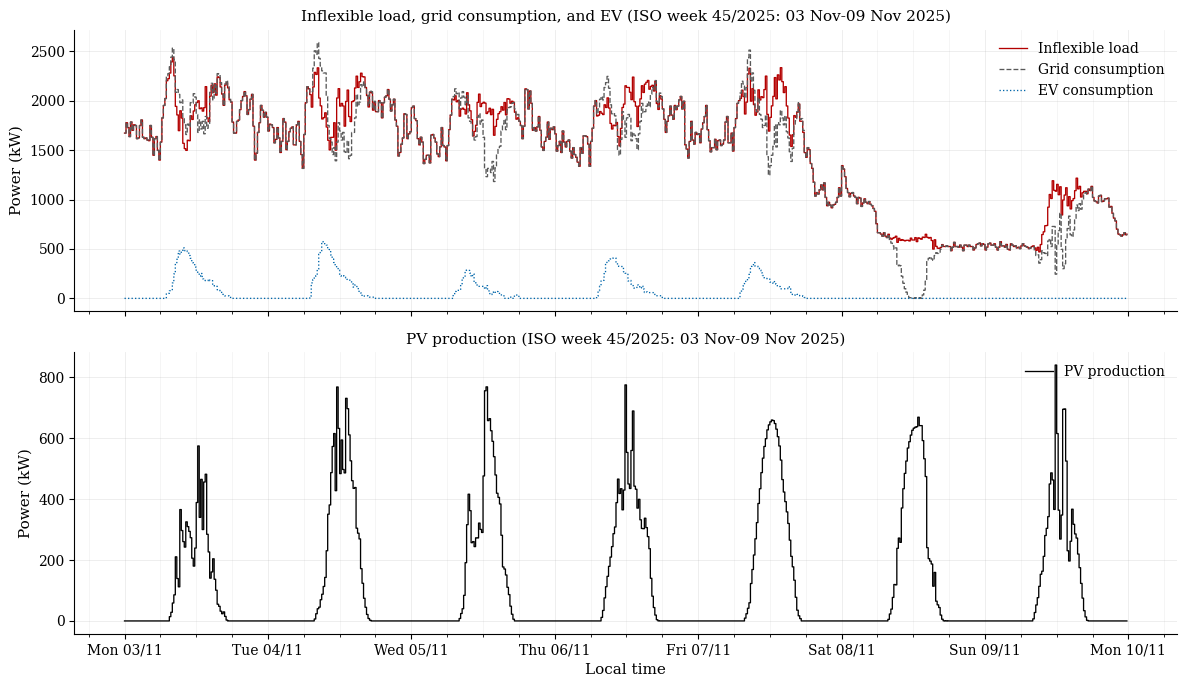

In [8]:
# Week profile: loads/grid/EV (top), PV (bottom); set YEAR + ISO_WEEK below
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt

# Canonical thesis rcParams (see STYLE_GUIDE_PLOTS.md); self-contained if run out of order
THESIS_STYLE = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.prop_cycle": mpl.cycler(color=["black", "#b30000"]),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
mpl.rcParams.update(THESIS_STYLE)
mpl.rcParams["lines.linewidth"] = 0.95  # thinner lines for dense multi-day plot

df = pd.read_csv("../data/plant1.csv")
df.columns = df.columns.str.strip()
df["timestamp"] = df["timestamp"].astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# --- pick any ISO week (Mon 00:00 … Sun 23:45 in data); change only these two ---
YEAR = 2025
ISO_WEEK = 45  # e.g. 37 -> 8–14 Sep 2025

win_start = pd.Timestamp(dt.date.fromisocalendar(YEAR, ISO_WEEK, 1))
win_end_excl = win_start + pd.Timedelta(days=7)
win_end_inclusive = win_end_excl - pd.Timedelta(minutes=15)  # last 15-min slot of Sunday

w = df[(df["timestamp"] >= win_start) & (df["timestamp"] < win_end_excl)].copy()

# kWh per 15 min -> average power over interval (kW)
for col in ("pv_production", "inflex_load", "grid_consumption", "ev"):
    w[f"{col}_kw"] = w[col].astype(float) * 4.0

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax_top.plot(
    w["timestamp"],
    w["inflex_load_kw"],
    color="#b30000",
    linestyle="-",
    drawstyle="steps-post",
    label="Inflexible load",
)
ax_top.plot(
    w["timestamp"],
    w["grid_consumption_kw"],
    color="0.35",
    linestyle="--",
    drawstyle="steps-post",
    label="Grid consumption",
)
ax_top.plot(
    w["timestamp"],
    w["ev_kw"],
    color="#0066aa",
    linestyle=":",
    drawstyle="steps-post",
    label="EV consumption",
)
ax_top.set_title(
    f"Inflexible load, grid consumption, and EV (ISO week {ISO_WEEK}/{YEAR}: "
    f"{win_start:%d %b}-{win_end_inclusive:%d %b %Y})"
)
ax_top.set_ylabel("Power (kW)")
ax_top.legend(loc="upper right", frameon=False)

ax_bottom.plot(
    w["timestamp"],
    w["pv_production_kw"],
    color="black",
    linestyle="-",
    drawstyle="steps-post",
    label="PV production",
)
ax_bottom.set_title(
    f"PV production (ISO week {ISO_WEEK}/{YEAR}: "
    f"{win_start:%d %b}-{win_end_inclusive:%d %b %Y})"
)
ax_bottom.set_ylabel("Power (kW)")
ax_bottom.set_xlabel("Local time")
ax_bottom.legend(loc="upper right", frameon=False)

for ax_ in (ax_top, ax_bottom):
    ax_.xaxis.set_major_locator(mdates.DayLocator())
    ax_.xaxis.set_major_formatter(mdates.DateFormatter("%a %d/%m"))
    ax_.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax_.grid(True, which="major", axis="both")
    ax_.grid(True, which="minor", axis="x", alpha=0.15)

fig.tight_layout()
plt.show()
